<a href="https://colab.research.google.com/github/nomadcodin/XAI_HybridNet/blob/main/Hybridnet_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

X-Consensus Score (XCS): 0.3435
X-Entropy: 0.0199


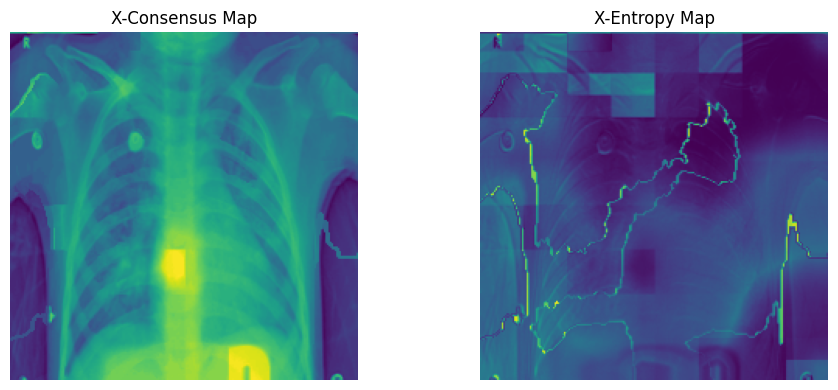

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- Utility functions --------

def load_and_normalize(path, size=(224, 224)):
    """
    Load image, convert to grayscale, resize, normalize to [0,1]
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size)
    img = img.astype(np.float32)
    img /= (img.max() + 1e-8)
    return img

# -------- Load explanation maps --------

gradcam = load_and_normalize("gradcam.png")
vit     = load_and_normalize("vit.png")
lime    = load_and_normalize("lime.png")
shap    = load_and_normalize("shap_.png")

maps = np.stack([gradcam, vit, lime, shap], axis=0)

# -------- X-Consensus Score (XCS) --------
# Pixel-wise minimum across all explanation maps
xcs_map = np.min(maps, axis=0)
XCS = xcs_map.mean()

# -------- X-Entropy (stability / disagreement) --------
# Variance across explanation maps
xentropy_map = np.var(maps, axis=0)
XEntropy = xentropy_map.mean()

print(f"X-Consensus Score (XCS): {XCS:.4f}")
print(f"X-Entropy: {XEntropy:.4f}")

# -------- Optional visualization --------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(xcs_map, cmap="viridis")
plt.title("X-Consensus Map")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(xentropy_map, cmap="viridis")
plt.title("X-Entropy Map")
plt.axis("off")

plt.tight_layout()
plt.show()
